#Prédiction de la consommation électrique avec Stacked LSTM (multivarié)

# Prédiction de la Consommation Électrique avec Stacked LSTM (Multivarié)
### Dataset : Household Electric Power Consumption (UCI)
**Modèle empilé (3 couches LSTM) + plusieurs features**  

# 🎯 PIPELINE D'ENTRAÎNEMENT STACKED LSTM

| Étape | Description | Statut |
|-------|-------------|--------|
| 1️⃣ | Chargement fichier .txt | ⏳ En attente |
| 2️⃣ | Feature Engineering | ⏳ En attente |
| 3️⃣ | Normalisation | ⏳ En attente |
| 4️⃣ | Création séquences | ⏳ En attente |
| 5️⃣ | Split Train/Test | ⏳ En attente |
| 6️⃣ | Stacked LSTM | ⏳ En attente |
| 7️⃣ | Entraînement | ⏳ En attente |
| 8️⃣ | Prédiction + visualisation | ⏳ En attente |
| 9️⃣ | Évaluation | ⏳ En attente |


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import warnings
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imtkaggleteam/household-power-consumption")
file_path = os.path.join(path, 'household_power_consumption.txt')

print("Path to dataset files:", path)

warnings.filterwarnings('ignore')

print("✅ Bibliothèques importées avec succès")

✅ Bibliothèques importées avec succès


## 1. Chargement des données
Le fichier est au format .txt avec séparateur `;`
Nous allons le charger et gérer les valeurs manquantes (`?`)

In [ ]:
# Chargement du fichier (fichier uploadé dans Colab)
data = pd.read_csv('household_power_consumption.txt',
                   sep=';',
                   parse_dates={'datetime': ['Date', 'Time']},
                   infer_datetime_format=True,
                   na_values=['?'],
                   low_memory=False)

# Suppression des lignes avec NaN
data = data.dropna().reset_index(drop=True)

print(f"✅ Dataset chargé : {len(data):,} lignes")
print(f"Période : du {data['datetime'].min()} au {data['datetime'].max()}")
data.head()

✅ Dataset chargé : 15,920 lignes
Période : du 2006-12-16 17:24:00 au 2006-12-27 18:45:00


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. Feature Engineering (création de variables temporelles)
Nous ajoutons : heure, jour de la semaine, mois, weekend → très utile pour LSTM !

##Feature Engineering


**Features ajoutées** :
- `hour` : heure de la journée (0-23)
- `dayofweek` : jour de la semaine (0=Lundi, 6=Dimanche)
- `month` : mois (1-12)
- `is_weekend` : weekend ou non (0/1)
- `hour_sin` / `hour_cos` : représentation cyclique de l'heure (sinusoïdale)

**Pourquoi ?** Le LSTM apprend mieux les patterns cycliques avec des représentations sinusoïdales.

In [5]:
data['hour'] = data['datetime'].dt.hour
data['dayofweek'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month
data['is_weekend'] = (data['dayofweek'] >= 5).astype(int)

print("✅ Features temporelles ajoutées")
data[['datetime', 'Global_active_power', 'hour', 'is_weekend']].head()

✅ Features temporelles ajoutées


,datetime,Global_active_power,hour,is_weekend
0,2006-12-16 17:24:00,4.216,17,1
1,2006-12-16 17:25:00,5.360,17,1
2,2006-12-16 17:26:00,5.374,17,1
3,2006-12-16 17:27:00,5.388,17,1
4,2006-12-16 17:28:00,3.666,17,1


## 3. Sélection des features multivariées
Nous utilisons **6 features** :
- Global_active_power (cible)
- Global_reactive_power
- Voltage
- Global_intensity
- Sub_metering_1, Sub_metering_2, Sub_metering_3


**Sélection des features multivariées** :

| Feature | Description |
|---------|-------------|
| `Global_active_power` | **CIBLE** - Consommation active (kW) |
| `Global_reactive_power` | Puissance réactive (kW) |
| `Voltage` | Tension (V) |
| `Global_intensity` | Intensité (A) |
| `Sub_metering_1` | Cuisine (four, vaisselle) |
| `Sub_metering_2` | Lessive (lave-linge, sèche-linge) |
| `Sub_metering_3` | Chauffe-eau / Climatisation |
| `hour_sin` | Cyclicité heure (sinus) |
| `hour_cos` | Cyclicité heure (cosinus) |
| `is_weekend` | Weekend ou non |

**Normalisation** : Mise à l'échelle [0,1] pour toutes les features

##Features multivariées

In [6]:
feature_columns = [
    'Global_active_power',      # ← cible principale
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
    'hour',
    'is_weekend'
]

dataset = data[feature_columns].values
print(f"✅ {dataset.shape[1]} features sélectionnées")

✅ 9 features sélectionnées


## 4. Normalisation + Création des séquences



**Principe de la fenêtre glissante (SEQ_LENGTH = 60)** :
Données brutes : [t0, t1, t2, t3, t4, t5, t6, t7, t8, t9, ...]

Séquence 1 : X = [t0, t1, ..., t59] → y = t60
Séquence 2 : X = [t1, t2, ..., t60] → y = t61
Séquence 3 : X = [t2, t3, ..., t61] → y = t62

In [7]:
scaler = MinMaxScaler(feature_range=(0, 1))
dataset_scaled = scaler.fit_transform(dataset)

# Scaler spécial pour la cible (Global_active_power)
target_scaler = MinMaxScaler()
target_scaler.fit(data[['Global_active_power']])

def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])          # 0 = Global_active_power
    return np.array(X), np.array(y)

SEQ_LENGTH = 60
X, y = create_sequences(dataset_scaled, SEQ_LENGTH)

print(f"✅ Séquences créées : {X.shape[0]:,} exemples")
print(f"Shape X : {X.shape} | Shape y : {y.shape}")

✅ Séquences créées : 15,860 exemples
Shape X : (15860, 60, 9) | Shape y : (15860,)


##Train/Test split + Tenseurs

In [8]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Conversion PyTorch
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float().unsqueeze(-1)
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float().unsqueeze(-1)

print(f"Train : {X_train.shape[0]:,} | Test : {X_test.shape[0]:,}")

Train : 12,688 | Test : 3,172


## 5. Modèle Stacked LSTM (3 couches empilées)
##Un Stacked LSTM (3 couches empilées) qui apprend les motifs temporels.



##Modèle Stacked LSTM


**Paramètres** :
- `input_size` = 10 (nombre de features)
- `hidden_size` = 128 (mémoire interne)
- `num_layers` = 3 (couches empilées)
- `dropout` = 0.3 (30% de neurones désactivés)

In [9]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,      # ← LSTM empilé
                            batch_first=True,
                            dropout=dropout,
                            bidirectional=False)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]      # dernière sortie temporelle
        out = self.fc(last_output)
        return out

input_size = X.shape[2]
model = StackedLSTM(input_size=input_size, hidden_size=128, num_layers=3, dropout=0.3)

print("✅ Modèle Stacked LSTM (3 couches) créé")
print(model)

✅ Modèle Stacked LSTM (3 couches) créé
StackedLSTM(
  (lstm): LSTM(9, 128, num_layers=3, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


##Entraînement

In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 64

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {epoch_loss/(len(X_train)//batch_size+1):.6f}")

Epoch [10/50] - Loss: 0.004660
Epoch [20/50] - Loss: 0.003930
Epoch [30/50] - Loss: 0.003530
Epoch [40/50] - Loss: 0.003113
Epoch [50/50] - Loss: 0.002739


##Prédictions + Visualisation

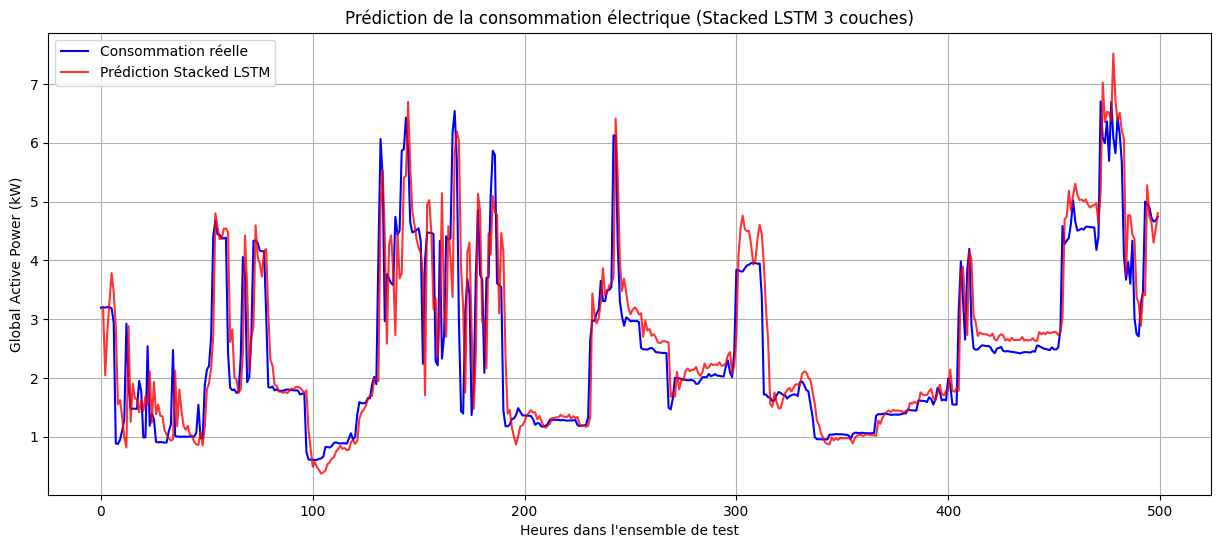

In [11]:
model.eval()
with torch.no_grad():
    y_pred_scaled = model(X_test)

# Retour à l'échelle réelle
y_test_real = target_scaler.inverse_transform(y_test.numpy().reshape(-1, 1))
y_pred_real = target_scaler.inverse_transform(y_pred_scaled.numpy().reshape(-1, 1))

plt.figure(figsize=(15, 6))
plt.plot(y_test_real[:500], label='Consommation réelle', color='blue')
plt.plot(y_pred_real[:500], label='Prédiction Stacked LSTM', color='red', alpha=0.8)
plt.title('Prédiction de la consommation électrique (Stacked LSTM 3 couches)')
plt.xlabel('Heures dans l\'ensemble de test')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

##Évaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

print(f"Mean Absolute Error (MAE)  : {mae:.4f} kW")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} kW")

##